# 03 Exploratory Data Analysis

Explore the cleaned dataset for distribution patterns, segment differences, and early signals that can inform Tableau views and statistical testing.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data/processed/cleaned_dataset.csv'

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

eda_df = pd.read_csv(DATA_PATH)
eda_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,previously_contacted,duration_minutes,age_group,balance_band,campaign_band
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,0,4.35,55-64,medium,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,0,2.52,35-44,low,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,0,1.27,25-34,low,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,0,1.53,45-54,medium,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,0,3.30,25-34,low,1


In [20]:
print(f'Rows: {len(eda_df):,}')
print(f'Columns: {len(eda_df.columns):,}')
print(f'Subscription rate: {eda_df["y"].mean():.2%}')

display(eda_df.describe(include='all').T)
display(eda_df.groupby('y')['age'].agg(['count', 'mean', 'median']))

Rows: 45,211
Columns: 22
Subscription rate: 11.70%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


,count,mean,median
y,,,
0,39922,40.838986,39.0
1,5289,41.670070,38.0


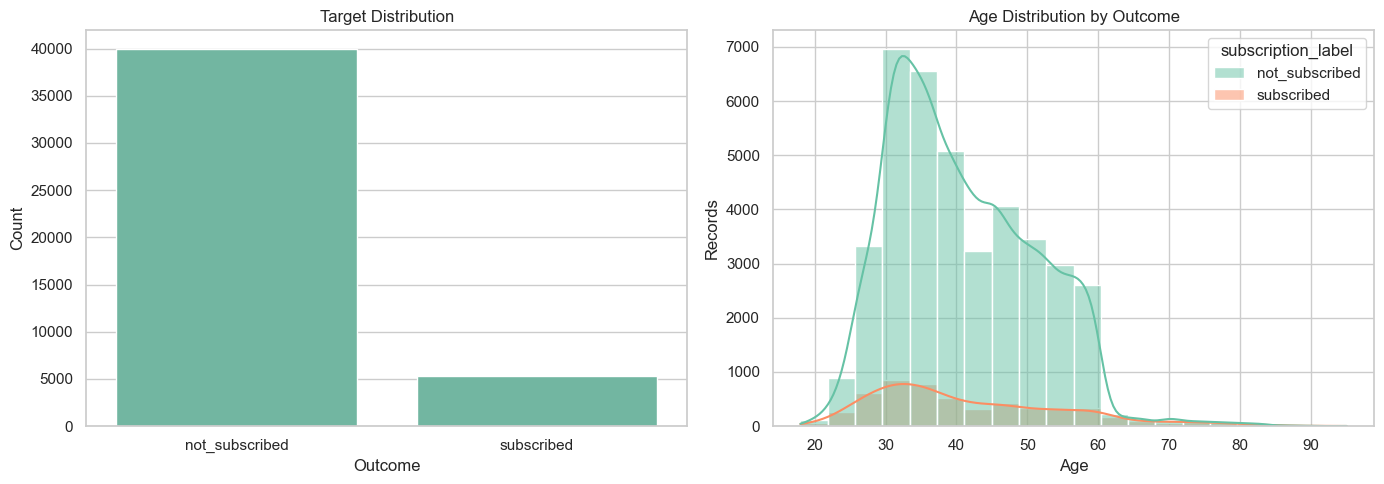

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=eda_df, x='subscription_label', ax=axes[0], order=['not_subscribed', 'subscribed'])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

sns.histplot(data=eda_df, x='age', hue='subscription_label', bins=20, kde=True, ax=axes[1])
axes[1].set_title('Age Distribution by Outcome')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Records')

plt.tight_layout()
plt.show()


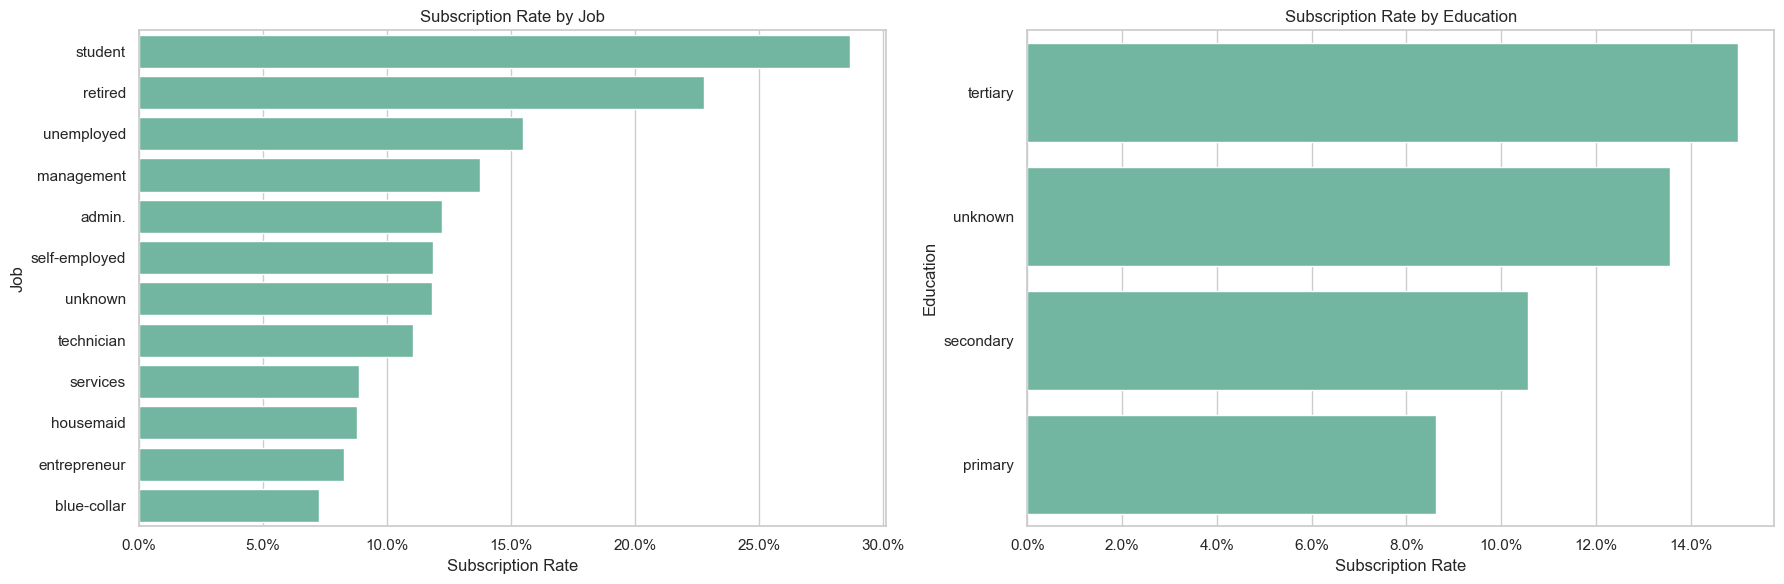

,job,subscription_rate
0,student,0.286780
1,retired,0.227915
2,unemployed,0.155027
3,management,0.137556
4,admin.,0.122027
5,self-employed,0.118429
6,unknown,0.118056
7,technician,0.110570
8,services,0.088830
9,housemaid,0.087903


,education,subscription_rate
0,tertiary,0.150064
1,unknown,0.135703
2,secondary,0.105594
3,primary,0.086265


In [12]:
job_rate = (
    eda_df.groupby('job', observed=False)['y']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='subscription_rate')
)

education_rate = (
    eda_df.groupby('education', observed=False)['y']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='subscription_rate')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=job_rate, y='job', x='subscription_rate', ax=axes[0])
axes[0].set_title('Subscription Rate by Job')
axes[0].set_xlabel('Subscription Rate')
axes[0].set_ylabel('Job')
axes[0].xaxis.set_major_formatter(PercentFormatter(1))

sns.barplot(data=education_rate, y='education', x='subscription_rate', ax=axes[1])
axes[1].set_title('Subscription Rate by Education')
axes[1].set_xlabel('Subscription Rate')
axes[1].set_ylabel('Education')
axes[1].xaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

display(job_rate)
display(education_rate)


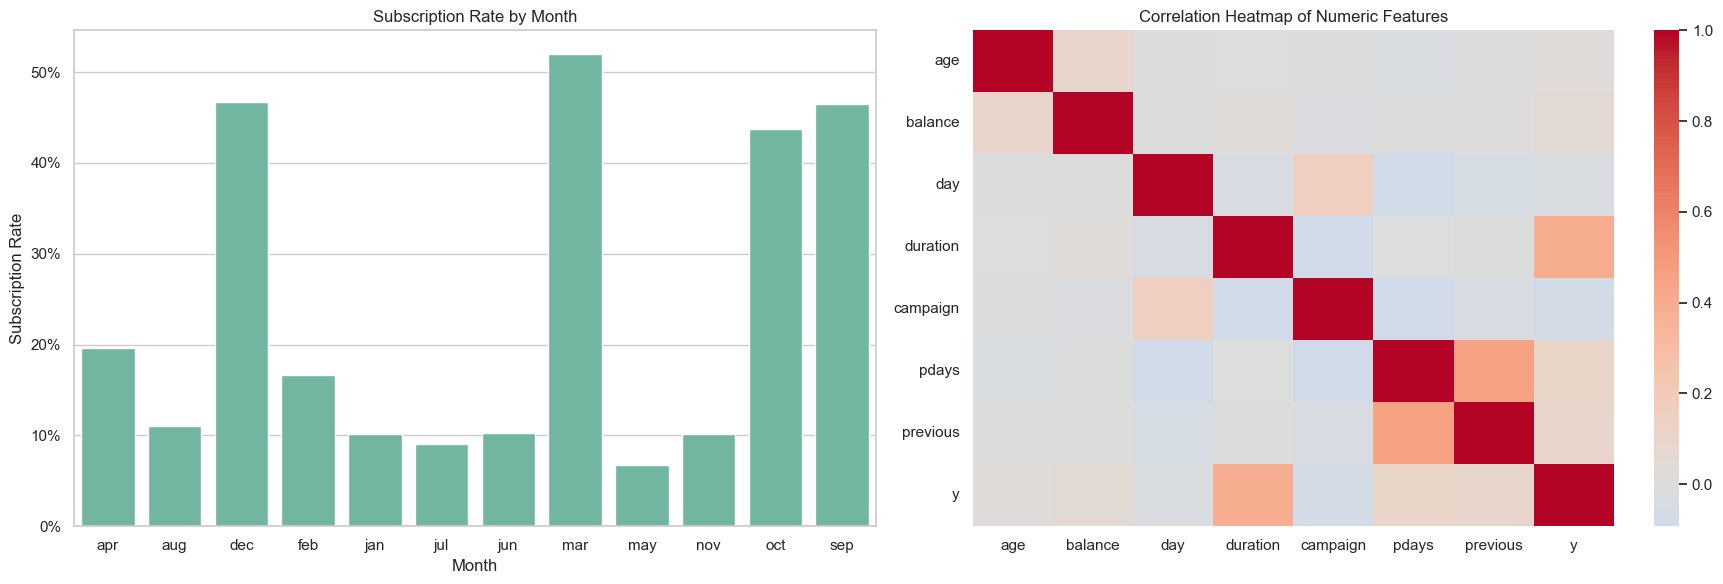

,month,subscription_rate
0,apr,0.196794
1,aug,0.110133
2,dec,0.467290
3,feb,0.166478
4,jan,0.101212
5,jul,0.090935
6,jun,0.102228
7,mar,0.519916
8,may,0.067195
9,nov,0.101511


,age,balance,day,duration,campaign,pdays,previous,y
age,1.000,0.098,-0.009,-0.005,0.005,-0.024,0.001,0.025
balance,0.098,1.000,0.005,0.022,-0.015,0.003,0.017,0.053
day,-0.009,0.005,1.000,-0.030,0.162,-0.093,-0.052,-0.028
duration,-0.005,0.022,-0.030,1.000,-0.085,-0.002,0.001,0.395
campaign,0.005,-0.015,0.162,-0.085,1.000,-0.089,-0.033,-0.073
pdays,-0.024,0.003,-0.093,-0.002,-0.089,1.000,0.455,0.104
previous,0.001,0.017,-0.052,0.001,-0.033,0.455,1.000,0.093
y,0.025,0.053,-0.028,0.395,-0.073,0.104,0.093,1.000


In [18]:
month_rate = (
    eda_df.groupby(['month'], dropna=False)['y']
    .mean()
    .reset_index(name='subscription_rate')
    .sort_values('month')
)

numeric_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'y',
]
corr = eda_df[numeric_cols].corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=month_rate, x='month', y='subscription_rate', ax=axes[0], order=month_rate['month'])
axes[0].set_title('Subscription Rate by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Subscription Rate')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

sns.heatmap(corr, cmap='coolwarm', center=0, ax=axes[1], annot=False)
axes[1].set_title('Correlation Heatmap of Numeric Features')

plt.tight_layout()
plt.show()

display(month_rate)
display(corr.round(3))
